* * *
<pre> NYU Paris            <i> Machine Learning - Summer 2023 </i></pre>
* * *


<h1 align="center"> Lab: the multilayer perceptron </h1>

<pre align="left"> June 07th 2023               <i> Author: Guillaume Staerman </i></pre>
* * *


##### Goal:
- Implement your Multilayer perceptron model

## Installing and importing Pytorch

In [1]:
import torch
from torchvision import datasets
from torchvision.transforms import ToTensor


# Versions of torch and torchvision have to be compatible.
# check here: https://github.com/pytorch/pytorch/wiki/PyTorch-Versions

In [2]:
import torchvision

In [3]:
print(torch.__version__)
print(torchvision.__version__)

2.0.1+cu118
0.15.2+cu118


### Loading and preparing the MNIST dataset

In [4]:
# Define training and testing data using the functions in the cell above.

train_data = datasets.MNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor()
)

test_data = datasets.MNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor()
)

100%|██████████| 9912422/9912422 [00:00<00:00, 117287141.22it/s]


Extracting data/MNIST/raw/train-images-idx3-ubyte.gz to data/MNIST/raw



100%|██████████| 28881/28881 [00:00<00:00, 22553657.39it/s]


Extracting data/MNIST/raw/train-labels-idx1-ubyte.gz to data/MNIST/raw



100%|██████████| 1648877/1648877 [00:00<00:00, 39473139.45it/s]


Extracting data/MNIST/raw/t10k-images-idx3-ubyte.gz to data/MNIST/raw



100%|██████████| 4542/4542 [00:00<00:00, 912906.30it/s]


Extracting data/MNIST/raw/t10k-labels-idx1-ubyte.gz to data/MNIST/raw



## Question 1

### Visualize some elements of the dataset:

torch.Size([60000, 28, 28])
torch.Size([10000, 28, 28])


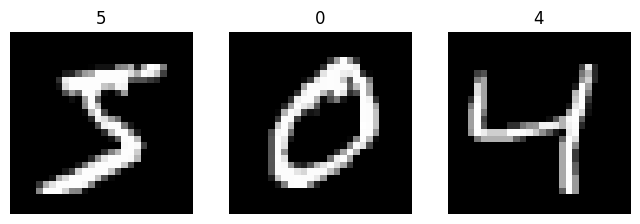

In [8]:
import matplotlib.pyplot as plt

# Assuming you have loaded the MNIST dataset into train_data and test_data variables

# Size of training data
print(train_data.data.shape)

# Size of testing data
print(test_data.data.shape)

labels_map = {
    0: "0",
    1: "1",
    2: "2",
    3: "3",
    4: "4",
    5: "5",
    6: "6",
    7: "7",
    8: "8",
    9: "9",
}

figure = plt.figure(figsize=(8, 8))
cols, rows = 3, 1

for i in range(1, cols * rows + 1):
    sample_idx = i - 1  # Index of the sample in the dataset
    img = train_data.data[sample_idx]  # Image data of the sample
    label = train_data.targets[sample_idx].item()  # Convert tensor to integer

    figure.add_subplot(rows, cols, i)
    plt.title(labels_map[label])
    plt.axis("off")
    plt.imshow(img.squeeze(), cmap="gray")

plt.show()


In [9]:
train_data.targets[0].item()

5

## Question 2

### Define a dataloader to construct a batch-wise iterator from your train/test data


In [10]:
from torch.utils.data import DataLoader

BATCH_SIZE = 4

trainloader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
testloader = DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False)

## Question 3

### Design your own Neural Network

In [11]:
import torch.nn as nn
import torch.nn.functional as F

# number of features (length of X columns)
input_dim = 28 * 28

# number of hidden layers
hidden_dim = 256

# number of classes (unique labels of y)
output_dim = 10

class MLP(nn.Module):
    def __init__(self):
        super(MLP, self).__init__()
        self.linear1 = nn.Linear(input_dim, hidden_dim)
        self.linear2 = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        h_relu = F.relu(self.linear1(x))
        y_pred = self.linear2(h_relu)
        return y_pred


## Question 4

### Train your neural network on the trainloader

In [14]:
from torch.nn.functional import nll_loss, cross_entropy
import torch.optim as optim

mlp = MLP()
print(mlp.parameters)

# Optimizer
epochs = 2
learning_rate = 1e-6
optimizer = optim.Adam(mlp.parameters(), lr=learning_rate)

# Choice of the loss
criterion = cross_entropy  # nll_loss

losses = []
for t in range(epochs):
    for i, data in enumerate(trainloader):
        inputs, labels = data
        inputs = inputs.view(inputs.shape[0], -1)
        optimizer.zero_grad()
        outputs = mlp(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())

        if not i % 2000:
            print(t, i, loss.item())


<bound method Module.parameters of MLP(
  (linear1): Linear(in_features=784, out_features=256, bias=True)
  (linear2): Linear(in_features=256, out_features=10, bias=True)
)>
0 0 2.329298734664917
0 2000 2.266144037246704
0 4000 2.232928991317749
0 6000 2.0433266162872314
0 8000 2.118363857269287
0 10000 2.0492305755615234
0 12000 1.8925498723983765
0 14000 1.8816863298416138
1 0 1.9394659996032715
1 2000 1.7892351150512695
1 4000 1.9964005947113037
1 6000 1.6620579957962036
1 8000 1.7346084117889404
1 10000 1.3643102645874023
1 12000 1.6671028137207031
1 14000 1.508603811264038


## Question 5

### Inspect the optimization procedure through the loss (plot the loss), what do you observe?

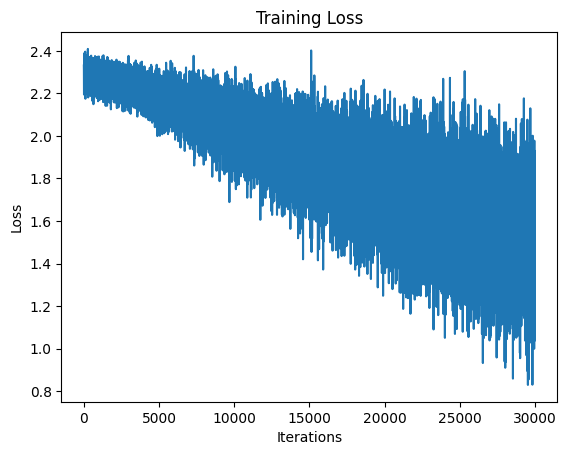

In [15]:

plt.plot(losses)
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.show()

## Question 6

### Evaluate the quality of your classifier on the test set

In [17]:
size_test = test_data.data.shape[0]

correct = 0
total = 0

for data in testloader:
    inputs, labels = data
    inputs = inputs.view(inputs.shape[0], -1)
    # Forward pass
    outputs = mlp(inputs)

    # Calculate the loss
    loss = criterion(outputs, labels)
    _, predicted = torch.max(outputs.data, 1)
    correct += (predicted == labels).sum().item()
    total += labels.size(0)

final_accuracy = 100 * correct / total

print("Final Accuracy: {:.2f}%".format(final_accuracy))

Final Accuracy: 79.53%


## Question 7 (Bonus)

### Repeat this training with different loss (nll/cross_entropy...) and different number of epochs. What do you observe?

In [18]:
epochs = 20
learning_rate = 1e-6
optimizer = optim.Adam(mlp.parameters(), lr=learning_rate)

# Choice of the loss
criterion = cross_entropy  # nll_loss

losses = []
for t in range(epochs):
    for i, data in enumerate(trainloader):
        inputs, labels = data
        inputs = inputs.view(inputs.shape[0], -1)
        optimizer.zero_grad()
        outputs = mlp(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())

        if not i % 2000:
            print(t, i, loss.item())
size_test = test_data.data.shape[0]

correct = 0
total = 0

for data in testloader:
    inputs, labels = data
    inputs = inputs.view(inputs.shape[0], -1)
    # Forward pass
    outputs = mlp(inputs)

    # Calculate the loss
    loss = criterion(outputs, labels)
    _, predicted = torch.max(outputs.data, 1)
    correct += (predicted == labels).sum().item()
    total += labels.size(0)

final_accuracy = 100 * correct / total

print("Final Accuracy: {:.2f}%".format(final_accuracy))

0 0 1.5460264682769775
0 2000 1.068974494934082
0 4000 1.5731064081192017
0 6000 1.478633165359497
0 8000 1.105455756187439
0 10000 1.2320873737335205
0 12000 1.0736455917358398
0 14000 1.3408509492874146
1 0 0.892667293548584
1 2000 1.324156403541565
1 4000 1.4211269617080688
1 6000 1.1953210830688477
1 8000 1.4555637836456299
1 10000 0.9634772539138794
1 12000 0.974194347858429
1 14000 0.9195233583450317
2 0 0.7641910910606384
2 2000 0.8396992683410645
2 4000 0.6562416553497314
2 6000 0.7535607814788818
2 8000 0.6549445390701294
2 10000 0.8636258840560913
2 12000 0.5147423148155212
2 14000 0.6618437170982361
3 0 0.4451422691345215
3 2000 1.1380354166030884
3 4000 1.2056869268417358
3 6000 1.2250666618347168
3 8000 0.7064899802207947
3 10000 0.9599345326423645
3 12000 0.9017034769058228
3 14000 0.5270248651504517
4 0 1.0859647989273071
4 2000 0.680173397064209
4 4000 0.8802546262741089
4 6000 0.8738128542900085
4 8000 1.0455130338668823
4 10000 0.6403987407684326
4 12000 0.41703146696

the total accuracy improved to 90% after setting epochs to 20, but the running time increased greatly. Another observation is loss of convergence. Some epochs converges much quicker than others.